# Prendo i dataset puliti

In [71]:
from pathlib import Path
import pickle
import pandas as pd  # serve per i .to_pickle/.read_pickle (anche se qui usi read_pickle)

# Sei in: src/Code/OnlyCode.ipynb
DATA_DIR = (Path.cwd().parent / "Datasets_puliti")

# --- carico i dataframe con gli stessi nomi di prima ---
train_MC  = pd.read_pickle(DATA_DIR / "train_MC.pkl")
test_MC   = pd.read_pickle(DATA_DIR / "test_MC.pkl")
train_ITA = pd.read_pickle(DATA_DIR / "train_ITA.pkl")
test_ITA  = pd.read_pickle(DATA_DIR / "test_ITA.pkl")
train_all = pd.read_pickle(DATA_DIR / "train_all.pkl")
test_all  = pd.read_pickle(DATA_DIR / "test_all.pkl")

# --- carico il vocabolario ---
with open(DATA_DIR / "vocabolario.pkl", "rb") as f:
    vocabolario = pickle.load(f)

print("✅ Dataset caricati da:", DATA_DIR)
print("train_all:", train_all.shape, "| test_all:", test_all.shape, "| vocab:", len(vocabolario))


✅ Dataset caricati da: c:\Users\marco\Desktop\IronyDetection\src\Datasets_puliti
train_all: (7971, 6) | test_all: (1810, 6) | vocab: 16397


In [72]:
# Tutti i dataset finali pronti:

train_MC = train_MC    # training set MC 
test_MC  = test_MC     # test set MC 
train_ITA = train_ITA  # training set IronITA 
test_ITA  = test_ITA   # test set IronITA 
train_all = train_all        # training set unito MC + IronITA
test_all  = test_all         # test set unito MC + IronITA

# di cui la struttura di ogni DataFrame è:
#   - text            : testo originale pulito
#   - label           : etichetta 0/1
#   - tokens          : lista di token (stringhe)
#   - tokens_int      : lista di token convertiti in ID (interi)
#   - input_ids       : lista di ID token padded/troncata a MAX_LEN
#   - attention_mask : lista di 1/0 per indicare token reali/padding


# vocabolario totale (MC + IronITA)
vocabolario = vocabolario # struttura: dict token -> {"token": String, "id": int, "freq": int}       di cui 0 è <PAD> e 1 è <UNK>

# gli id sono messi in ordine crescente a partire da 0 di frequenza decrescente


# Trasformiamo il dataset in TENSORE
Una classe specializzata di PYTHORCH

In [73]:
import torch

# Classe specializzata di pytorch, rappresenterà il dataset
class TokenDataset(torch.utils.data.Dataset):

    # passo un dataset
    def __init__(self, df):
        self.input_ids = df["input_ids"].values  # lista di 64 ID_token padded, (basati dal vocabolario totale)
        self.labels = df["label"].values         # etichetta 0/1 per ogni frase (ironico non ironico)
        self.texts = df["text"].values           # testo originale pulito per ogni frase
        self.masks = df["attention_mask"].values # lista di 1/0 per ogni frase (1=token reale, 0=pad)


    # ritorna la lunghezza del dataset (4000)
    def __len__(self):
        return len(self.labels)

    # dato un id frase, torna i TORCH TENSOR corrispondenti
    def __getitem__(self, idx):
        ids = torch.tensor(self.input_ids[idx], dtype=torch.long)   # lista dei 64 ID della frase idx
        label = torch.tensor(self.labels[idx], dtype=torch.float32)  # label 0/1 della frase idx
        text = self.texts[idx] 
        mask = torch.tensor(self.masks[idx], dtype=torch.float32)                                      # testo originale della frase idx
        return ids, label, text, mask
    
    

In [74]:
Tensor_TrainAll = TokenDataset(train_all)
Tensor_TestAll  = TokenDataset(test_all)
Tensor_TrainMC  = TokenDataset(train_MC)
Tensor_TestMC   = TokenDataset(test_MC)
Tensor_TrainITA = TokenDataset(train_ITA)
Tensor_TestITA  = TokenDataset(test_ITA)


In [75]:
ids0, label0, text0, mask0 = Tensor_TrainMC[0] 

print(text0) 
print(ids0)      
print(label0)
print(mask0) 

ogni volta che parte un corteo radicale, il centro città diventa un percorso a ostacoli.
tensor([  60,   83,    5,  146,   11, 1115, 2447,    3,    7,  439,  351,  497,
          11,  904,   12, 7301,    2,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
tensor(1.)
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


# Definiamo la classe MODEL

In [76]:
'''
CLASSE FINALE, A CUI VOGLIAMO ARRIVARE
DOBBIAMO DEFINIRE TUTTI I LAYER PRIMA

import torch
import torch.nn as nn

# CLASSE MODEL
# rappresenta l'intero modello end-to-end
# nel forwar definisco tutti i passaggi che il mio dataset dovrà fare

class IronyEndToEndModel(nn.Module):
    
    def __init__(self, 
                 dim_vocabolario,      # dimensione del vocabolario (usiamo uno unico per tutti i dataset ITA + MC)
                 dim_wordVector=128,   # dimensione del wordVector (128 feature)
                 dim_frase=64,         # lunghezza massima della frase (64 parole)
                 num_heads=4):         # numero di teste della MHSA    
        super().__init__()


        # Istanzio i layer senza fare il forward

        # EMBEDDING LAYER 
        self.embedding_layer = EmbeddingLayer(      
            dim_vocabolario=dim_vocabolario,
            dim_wordVector=dim_wordVector,
            dim_frase=dim_frase,
            padding_idx=0
        )

        # MHSA LAYER
        self.mhsa = MultiHeadSelfAttention(      
            dim_model=dim_wordVector,
            num_heads=num_heads
        )

        # PRIMO RESIDUALNORM LAYER
        self.residual1 = ResidualLayerNorm(      
            dim_model=dim_wordVector
        )
        

        # FFN LAYER
        self.ffn = PositionWiseFFN(              
            dim_model=dim_wordVector
        )

        # SECONDO RESIDUALNORM LAYER
        self.residual2 = ResidualLayerNorm(      
            dim_model=dim_wordVector
        )

        # MEAN POOLING LAYER
        self.mean_pool = MeanPooling()            


        # CLASSIFICATORE FINALE
        self.classifier = SentenceClassifier(       
            dim_model=dim_wordVector
        )

    # Chiama in automatico i forward di tutti i layer
    def forward(self, input_ids, mask):

        # !! input_ids è un tensore MATRICE (numero di frasi x 64 parole(ID) per frase)
        # 4000x64 se metto tutto il training set
        # 32x64 se metto solo un subset di 32 frasi

        # Embedding Layer 
        embeddings = self.embedding_layer(input_ids) 
    
        # MHSA Layer
        attn_out = self.mhsa(embeddings, mask=mask)

        # Primo ResidualNorm Layer
        z1 = self.residual1(embeddings, attn_out)   
        
        # FFN Layer
        ffn_out = self.ffn(z1)    

        # Secondo ResidualNorm Layer
        z2 = self.residual2(z1, ffn_out)      

        # Mean Pooling Layer
        sent_repr = self.mean_pool(z2, mask)        
        
        # Classificatore Finale
        logits = self.classifier(sent_repr)         
        logits = logits.squeeze(-1)                 

        return logits    # otteniamo le predizioni finali y'
    
    
'''

"\nCLASSE FINALE, A CUI VOGLIAMO ARRIVARE\nDOBBIAMO DEFINIRE TUTTI I LAYER PRIMA\n\nimport torch\nimport torch.nn as nn\n\n# CLASSE MODEL\n# rappresenta l'intero modello end-to-end\n# nel forwar definisco tutti i passaggi che il mio dataset dovrà fare\n\nclass IronyEndToEndModel(nn.Module):\n    \n    def __init__(self, \n                 dim_vocabolario,      # dimensione del vocabolario (usiamo uno unico per tutti i dataset ITA + MC)\n                 dim_wordVector=128,   # dimensione del wordVector (128 feature)\n                 dim_frase=64,         # lunghezza massima della frase (64 parole)\n                 num_heads=4):         # numero di teste della MHSA    \n        super().__init__()\n\n\n        # Istanzio i layer senza fare il forward\n\n        # EMBEDDING LAYER \n        self.embedding_layer = EmbeddingLayer(      \n            dim_vocabolario=dim_vocabolario,\n            dim_wordVector=dim_wordVector,\n            dim_frase=dim_frase,\n            padding_idx=0\n   

## Definiamo i vari layer

### Embeddings
info parola + info posizione

In [77]:
import math
import torch
import torch.nn as nn

class EmbeddingLayer(nn.Module):
    def __init__(self, dim_vocabolario, dim_wordVector, dim_frase, padding_idx=0):
        super().__init__()

        self.token_embedding = nn.Embedding(
                num_embeddings=dim_vocabolario,   # dim vocabolario
                embedding_dim=dim_wordVector,     # 128
                padding_idx=padding_idx           # id = 0 per il padding
            )     
        # i token <PAD> avranno wordVector = [0.0, 0.0, ..., 0.0] - no informazione
        # però verra sommata l'informazione del posVector anche a loro (standard Transformer)

        self.pos_embedding = nn.Embedding(
                num_embeddings=dim_frase,      # 64
                embedding_dim=dim_wordVector   # 128
        )
      
        self.dim_frase = dim_frase              # 64 
        self.dim_wordVector = dim_wordVector   # 128


    def forward(self, input_ids):
        # nel model è il primo layer, riceve input_ids 
        # cioè una matrice (numero di frasi x 64 parole(ID) per frase)
        # 4000x64 frasi totali oppure 32x64 se subset di 32 frasi

        # Ottengo le dimensioni del subset, e lunghezza frase
        batch_size, seq_len = input_ids.size()  

        # Genera i wordVectors per ogni parola nella frase
        token_emb = self.token_embedding(input_ids)  
        
        # adatto la dimensione del tensore
        positions = torch.arange(seq_len, device=input_ids.device)    
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)  

        # genera i posVectors per ogni posizione nella frase
        pos_emb = self.pos_embedding(positions)
       
        # Ogni parola avrà un vettore (di 128) info parola + info posizione
        # embeddings = token_emb + pos_emb  (questo è il metodo senza normalizzazione)


        # info parola + info posizione con normalizzazione scalare 
        embeddings = (token_emb * math.sqrt(self.dim_wordVector)) + pos_emb


        return embeddings

### Multi head self attention

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math



class MultiHeadSelfAttention(nn.Module):

    def __init__(self, dim_model=128, num_heads=4):
        super().__init__()

        assert dim_model % num_heads == 0, "dim_model deve essere divisibile per num_heads"

        self.dim_model = dim_model                    
        self.num_heads = num_heads                   
        self.head_dim  = dim_model // num_heads   # feature per head : 128/4 = 32

        # pesi da calcolare
        self.W_q = nn.Linear(dim_model, dim_model) # otteniamo Q = "che tipo di altra parola cerco/affine in una frase?"
        self.W_k = nn.Linear(dim_model, dim_model) # otteniamo K = "che tipo di parola è questa?"
        self.W_v = nn.Linear(dim_model, dim_model) # otteniamo V = "che info porto, quanto pesa quella parola sul contesto?"
        
        self.W_o = nn.Linear(dim_model, dim_model) # trasformazione finale che unisce le varie heads
        


    # viene passato x, dopo embedding layer (per ogni frase ogni parola è un wordVector di 128)
    # x è un tesore 4000x64x128 (numero di frasi x lunghezza frase x dim wordVector)
    def forward(self, x, mask=None):
        
        B, L, D = x.size()   # batch size(4000), lunghezza frase(64), dimensione modello(128)

        # GENERO Q,K,V DALLE MATRICI DEI PESI W_q W_k W_v
        Q = self.W_q(x)  # Q = W_q * X + bq  (sempre 4000x64x128)
        K = self.W_k(x)  # K = W_k * X + bk  (sempre 4000x64x128)
        V = self.W_v(x)  # V = W_v * X + bv  (sempre 4000x64x128)

        # QUI FACCIO LO SPLIT NELLE VARIE HEADS
        Q = Q.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        
        # CALCOLO L'ATTENZIONE A
        scores = torch.matmul(Q, K.transpose(-2, -1))  # calcolo A = Q * K^T  (64x64)
        scores = scores / math.sqrt(self.head_dim)  # normalizzo
        
        # uso la mask => Annullo l'attenzione delle parole sui token di padding
        if mask is not None:
            mask_expanded = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask_expanded == 0, float('-inf'))

        # la softmax trasforma i -inf in 0, quindi i padding non avranno influenza su altri token
        A = F.softmax(scores, dim=-1) # applico la softmax, ora l'attenzione è distribuita su tutte le feature


        # CALCOLO L'USCITA M
        M = torch.matmul(A, V) # calcolo M = A * V
        M = M.transpose(1, 2).contiguous().view(B, L, D)
        
        out = self.W_o(M)  
        # Out = W_o * M + b_o  (4000x64x128)
        
        return out

### Residual e normalizzation

In [79]:
import torch
import torch.nn as nn

# Residual + LayerNorm
class ResidualLayerNorm(nn.Module):
    def __init__(self, dim_model=128): 
        super().__init__()

        self.layer_norm = nn.LayerNorm(dim_model)

    # passo X output del embedding layer e out output del layer precedente (MHSA o FFN)
    def forward(self, x, out):

        # sommo feature per feature,
        # unisco le informazioni del nuovo layer con quello precedente (così non perdo info)
        y = x + out
        
        # normalizzazione layer norm
        z = self.layer_norm(y) 
        # ho i paramtri gamma e beta da addestrare
        
        return z # (4000x64x128)

### Feed Forward Network

In [80]:
import torch
import torch.nn as nn

# PER OGNI PAROLA (input 128 feature) APPLICHIAMO UNA RETE FFN
# FULLY CONNECTED, primo strato di 512 neuroni, e gli applichiamo la relu
# Poi un secondo strato di 128, che sarà l'output finale
# CIOE' LA NUOVA WORDVECTOR DELLA PAROLA, trasformata maggiore espressione

class PositionWiseFFN(nn.Module):
    def __init__(self, dim_model=128, dim_hidden=None):
        super().__init__()
        
        # Versione potenziata, il primo layer espande le feature a 512
        if dim_hidden is None:
            dim_hidden = dim_model * 4   # = 512

        self.linear1 = nn.Linear(dim_model, dim_hidden)
        self.activation = nn.ReLU()     
        self.linear2 = nn.Linear(dim_hidden, dim_model)

    def forward(self, x):
        z = self.linear1(x)      
        h = self.activation(z)
        y = self.linear2(h)      
        return y
    
    # ritorna lo stesso tensore (4000x64x128) ma le parole saranno cambiate


Qui viene riapplicata la seconda Residual layer norm

### Mean Pooling

In [81]:
import torch
import torch.nn as nn

# Obbiettivo è rappresentare una frase non più come una matrice (64x128)
# ma come un vettore (1x128) , che rappresenta la sintesi della frase
# andrò a fare una media delle feature di tutte le parole della frase => 128 feature per frase

class MeanPooling(nn.Module):
    def __init__(self):
        super().__init__()
        

    # viene passato X (4000x64x128) e la mask (4000x64), 
    # deve ritornare un tensore (4000x128), ogni riga è una frase, non una parola
    def forward(self, x, mask):
       
        mask_expanded = mask.unsqueeze(-1)     
        mask_expanded = mask_expanded.to(x.dtype)    

        # moltiplicazione elemento per elemento (non prodotto scalare)
        # e mask_expanded si adatta e diventa 4000x64x128 (ripetendo la maschera su tutta la riga)
        # trasforma in 0 tutti i vettori delle parole padding => non voglio rappresentarle nella media delle feature
        x_masked = x * mask_expanded        
        
        sum_x = x_masked.sum(dim=1)   
        lengths = mask_expanded.sum(dim=1)          

        lengths = torch.clamp(lengths, min=1e-8)
        sent_repr = sum_x / lengths                  
        return sent_repr   

### Classificatore 

In [82]:
import torch
import torch.nn as nn

# Alla fine quindi prendiamo la nuova rappresentazione della frase (da 64 a 128 elmenti)
# e la diamo in pasto a un semplice classificatore binario (ironico/non ironico)

# Quindi una rete con 128 input e 1 output (logit)
#  NON VIENE APPLICATA QUA LA SIGMOIDE

class SentenceClassifier(nn.Module):
    def __init__(self, dim_model=128):  
        super().__init__()
        
        # singolo strato Fully Connected
        self.linear = nn.Linear(dim_model, 1) 

        
    def forward(self, x):
        
        logits = self.linear(x)   # un valore reale per ogni frase (4000x1)
        
        return logits

# MODELLO IRONYDETECTION

In [83]:
import torch
import torch.nn as nn

# CLASSE MODEL
# rappresenta l'intero modello end-to-end
# nel forwar definisco tutti i passaggi che il mio dataset dovrà fare

class IronyEndToEndModel(nn.Module):
    
    def __init__(self, 
                 dim_vocabolario,      # dimensione del vocabolario (usiamo uno unico per tutti i dataset ITA + MC)
                 dim_wordVector=128,   # dimensione del wordVector (128 feature)
                 dim_frase=64,         # lunghezza massima della frase (64 parole)
                 num_heads=4):         # numero di teste della MHSA    
        super().__init__()


        # Istanzio i layer senza fare il forward

        # EMBEDDING LAYER 
        self.embedding_layer = EmbeddingLayer(      
            dim_vocabolario=dim_vocabolario,
            dim_wordVector=dim_wordVector,
            dim_frase=dim_frase,
            padding_idx=0
        )

        # MHSA LAYER
        self.mhsa = MultiHeadSelfAttention(      
            dim_model=dim_wordVector,
            num_heads=num_heads
        )

        # PRIMO RESIDUALNORM LAYER
        self.residual1 = ResidualLayerNorm(      
            dim_model=dim_wordVector
        )
        

        # FFN LAYER
        self.ffn = PositionWiseFFN(              
            dim_model=dim_wordVector
        )

        # SECONDO RESIDUALNORM LAYER
        self.residual2 = ResidualLayerNorm(      
            dim_model=dim_wordVector
        )

        # MEAN POOLING LAYER
        self.mean_pool = MeanPooling()            


        # CLASSIFICATORE FINALE
        self.classifier = SentenceClassifier(       
            dim_model=dim_wordVector
        )

    # Chiama in automatico i forward di tutti i layer
    def forward(self, input_ids, mask):

        # !! input_ids è un tensore MATRICE (numero di frasi x 64 parole(ID) per frase)
        # 4000x64 se metto tutto il training set
        # 32x64 se metto solo un subset di 32 frasi

        # Embedding Layer 
        embeddings = self.embedding_layer(input_ids) 
    
        # MHSA Layer
        attn_out = self.mhsa(embeddings, mask=mask)

        # Primo ResidualNorm Layer
        z1 = self.residual1(embeddings, attn_out)   
        
        # FFN Layer
        ffn_out = self.ffn(z1)    

        # Secondo ResidualNorm Layer
        z2 = self.residual2(z1, ffn_out)      

        # Mean Pooling Layer
        sent_repr = self.mean_pool(z2, mask)        
        
        # Classificatore Finale
        logits = self.classifier(sent_repr)         
        logits = logits.squeeze(-1)                 

        return logits    
    

In [84]:
dim_vocabolario = len(vocabolario)
IstanzaModelProva = IronyEndToEndModel(
    dim_vocabolario=dim_vocabolario,
    dim_wordVector=128,
    dim_frase=64,
    num_heads=4
)


In [85]:
# DATO UN MODELLO POSSO ACCEDERE AI SUOI PESI
# model.named_parameters() ritorna un iterabile di (nome_peso/layer, tensore_peso)

def stampa_pesi_modello(model):
    print("ELENCO COMPLETO DEI PESI DEL MODELLO:\n")
    for name, param in model.named_parameters():
        print(f"{name:60s}  shape = {tuple(param.shape)}")

stampa_pesi_modello(IstanzaModelProva)

ELENCO COMPLETO DEI PESI DEL MODELLO:

embedding_layer.token_embedding.weight                        shape = (16397, 128)
embedding_layer.pos_embedding.weight                          shape = (64, 128)
mhsa.W_q.weight                                               shape = (128, 128)
mhsa.W_q.bias                                                 shape = (128,)
mhsa.W_k.weight                                               shape = (128, 128)
mhsa.W_k.bias                                                 shape = (128,)
mhsa.W_v.weight                                               shape = (128, 128)
mhsa.W_v.bias                                                 shape = (128,)
mhsa.W_o.weight                                               shape = (128, 128)
mhsa.W_o.bias                                                 shape = (128,)
residual1.layer_norm.weight                                   shape = (128,)
residual1.layer_norm.bias                                     shape = (128,)
ffn.linear1.

## Dataloader
Divide in subset i dataset mescolando le frasi = **Stocastic gradient**

In [86]:
'''
Tensor_TrainAll = TokenDataset(train_all)
Tensor_TestAll  = TokenDataset(test_all)
Tensor_TrainMC  = TokenDataset(train_MC)
Tensor_TestMC   = TokenDataset(test_MC)
Tensor_TrainITA = TokenDataset(train_ITA)
Tensor_TestITA  = TokenDataset(test_ITA)

'''

from torch.utils.data import DataLoader

# DataLoader per il training MC, aiuta a costruire i subset della dimensione giusta
train_loader_MC = DataLoader(
    Tensor_TrainMC,   
    batch_size=32,    # 32 frasi per volta per subset
    shuffle=True      # frasi mescolate, e non selezionate ordinate
)
test_loader_MC = DataLoader(
    Tensor_TestMC,
    batch_size=32,
    shuffle=False     # nel test set non serve mescolare
)
train_loader_ITA = DataLoader(
    Tensor_TrainITA,
    batch_size=32,
    shuffle=True
)
test_loader_ITA = DataLoader(
    Tensor_TestITA,
    batch_size=32,
    shuffle=False
)
train_loader_ALL = DataLoader(
    Tensor_TrainAll,
    batch_size=32,
    shuffle=True
)
test_loader_ALL = DataLoader(
    Tensor_TestAll,
    batch_size=32,
    shuffle=False
)

#-------------------------------------------------------------------
# vero output da dare al modello :
# Loader = classe contenitore, ma che gestisce i subset in automatico (32 frasi x subset)

loader_trainMC = train_loader_MC
loader_testMC  = test_loader_MC
loader_trainITA = train_loader_ITA
loader_testITA  = test_loader_ITA
loader_trainALL = train_loader_ALL
loader_testALL  = test_loader_ALL

# ADDESTRAMENTO

### Funzione di addestramento
Stampa la funzione di costo media J per ogni epoca (ogni ciclo di tutto il dataset)  
L'obbiettivo è che si riduca il più possibile dopo tot epoche

In [87]:
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=5):
    
    train_losses = []

    for epoch in range(num_epochs):
        print(f"\nEPOCH {epoch+1}")
        
        model.train()  # modalità training (attiva alcune funzionalità per l'addestramento come il dropout)

        running_loss = 0.0  # somma la loss totale del epoca, e fa la media / subset alla fine

        for i, (batch_ids, batch_labels, batch_texts, batch_mask) in enumerate(train_loader):
            # sposto tutto NELLA MEMORIA DELLA GPU se disponibile
            batch_ids    = batch_ids.to(device)          # [B, 64]
            batch_labels = batch_labels.to(device)       # [B]
            batch_mask   = batch_mask.to(device)         # [B, 64]

            # azzero il gradiente
            optimizer.zero_grad()

            # forward: il modello ora vuole anche la mask
            logits = model(batch_ids, batch_mask)        # [B]

            # prendo le etichette 0 non ironico, 1 ironico del dataset e converto in float (0.0 / 1.0)
            labels_flat = batch_labels.float()           # [B]

            # calcolo la loss
            loss = criterion(logits, labels_flat)

            # calcolo il gradiente
            loss.backward()

            # aggiornamento pesi
            optimizer.step()

            # logging
            J = loss.item() # contiene la loss media del batch
            running_loss += J * batch_ids.size(0)  # J * numero di frasi nel batch (32) = somma totale (no media)
            # accumulo la somma totale di tutti i batch del epoca

            # ogni 50 batch, stampo una loss parziale di debug per quel epoca
            if i % 50 == 0:
                print(f"  batch {i:3d}  loss = {J:.4f}")

        
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"\nLoss media epoca {epoch+1}: {epoch_loss:.4f}")
        train_losses.append(epoch_loss)

    return train_losses


### Istanziamo il modello e addestriamo

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim

# istanziamo il modello, opzione di usare la scheda grafica se disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IronyEndToEndModel(
    dim_vocabolario=len(vocabolario),
    dim_wordVector=128,
    dim_frase=64,
    num_heads=4
).to(device)

# istanziamo l'oggetto che gestisce la loss(quindi ha anche J) e calcola i gradienti di J
criterion = nn.BCEWithLogitsLoss()

# istaniziamo l'oggetto che aggiorna i pesi del modello
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 40

train_losses = train_model(
    model,
    loader_trainALL,
    criterion,
    optimizer,
    device,
    num_epochs=num_epochs
)


EPOCH 1


  batch   0  loss = 0.6993
  batch  50  loss = 0.5855
  batch 100  loss = 0.6472
  batch 150  loss = 0.7526
  batch 200  loss = 0.6407

Loss media epoca 1: 0.6286

EPOCH 2
  batch   0  loss = 0.4453
  batch  50  loss = 0.5926
  batch 100  loss = 0.5867
  batch 150  loss = 0.4752
  batch 200  loss = 0.6285

Loss media epoca 2: 0.5307

EPOCH 3
  batch   0  loss = 0.5090
  batch  50  loss = 0.4123
  batch 100  loss = 0.5620
  batch 150  loss = 0.5017
  batch 200  loss = 0.3580

Loss media epoca 3: 0.4628

EPOCH 4
  batch   0  loss = 0.4189
  batch  50  loss = 0.5323
  batch 100  loss = 0.4795
  batch 150  loss = 0.2556
  batch 200  loss = 0.5456

Loss media epoca 4: 0.4005

EPOCH 5
  batch   0  loss = 0.4003
  batch  50  loss = 0.3979
  batch 100  loss = 0.4720
  batch 150  loss = 0.4208
  batch 200  loss = 0.3114

Loss media epoca 5: 0.3540

EPOCH 6
  batch   0  loss = 0.1871
  batch  50  loss = 0.2362
  batch 100  loss = 0.2062
  batch 150  loss = 0.2886
  batch 200  loss = 0.4337

Loss

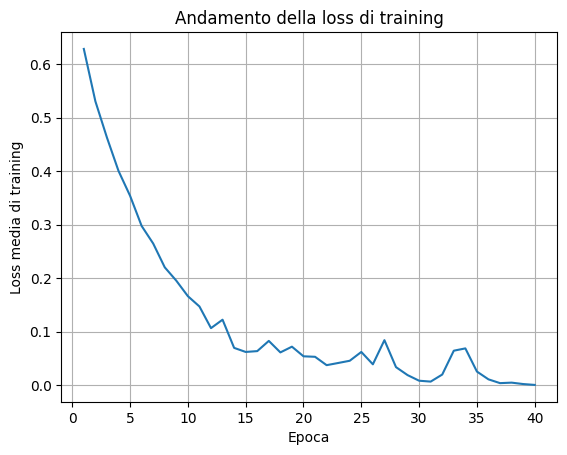

In [89]:
# Disegno il grafico del training loss

import matplotlib.pyplot as plt

# Assumiamo che train_losses sia già disponibile come lista
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses)
plt.xlabel("Epoca")
plt.ylabel("Loss media di training")
plt.title("Andamento della loss di training")
plt.grid(True)

plt.show()

# Evaluation del modello
## Validation set

In [90]:
# Splitto il training set in training e validation set (80% train, 20% val)

'''
Prima facevo : 

train_loader_ALL = DataLoader(
    Tensor_TrainAll,
    batch_size=32,
    shuffle=True
)
    Tensor_TestAll


 Tensor_TrainAll è il dataset completo di training (8000 frasi)
 => lo splitto (RANDOMICAMENTE) in 6400 frasi train e 1600 frasi validation

 
'''

from torch.utils.data import random_split, DataLoader

# percentuale di validation (20%)
val_ratio = 0.2

# dimensioni
train_size = int((1 - val_ratio) * len(Tensor_TrainAll))
val_size   = len(Tensor_TrainAll) - train_size

# split casuale
splitted_train_dataset, splitted_val_dataset = random_split(
    Tensor_TrainAll,
    [train_size, val_size]
)


# creo i DataLoader per training e validation set (divido in batch di 32 frasi)


train_loader_ALL = DataLoader(
    splitted_train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader_ALL = DataLoader(
    splitted_val_dataset,
    batch_size=32,
    shuffle=False
)




Aggiungo il validation con il train model

In [91]:
def train_model_conVal(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):
    
    train_losses = []
    eval_losses  = []

    for epoch in range(num_epochs):
        print(f"\nEPOCH {epoch+1}")
        model.train()  # modalità training

        running_loss = 0.0  # somma loss training epoca

        for i, (batch_ids, batch_labels, batch_texts, batch_mask) in enumerate(train_loader):

            batch_ids    = batch_ids.to(device)
            batch_labels = batch_labels.to(device)
            batch_mask   = batch_mask.to(device)

            optimizer.zero_grad()

            logits = model(batch_ids, batch_mask)
            labels_flat = batch_labels.float()

            loss = criterion(logits, labels_flat)

            loss.backward()
            optimizer.step()

            J = loss.item()
            running_loss += J * batch_ids.size(0)

            if i % 50 == 0:
                print(f"  train batch {i:3d}  loss = {J:.4f}")

        train_epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_epoch_loss)

        # print(f"Loss media TRAIN epoca {epoch+1}: {train_epoch_loss:.4f}")

        # =========================
        # VALIDATION
        # =========================

        # Finita un epoca di training, valuto l'errore medio su tutto il validation set

        model.eval()  # modalità eval , disattiva funzionalità del training come il dropout

        running_eval_loss = 0.0  # accumula la loss di ogni batch calcolata sul validation set

        with torch.no_grad():
            for batch_ids, batch_labels, batch_texts, batch_mask in val_loader:  # per ogni batch del validation set

                # metto il batch nella memoria della GPU se disponibile
                batch_ids    = batch_ids.to(device)
                batch_labels = batch_labels.to(device)
                batch_mask   = batch_mask.to(device)

                # FACCIO IL FORWARD PASS con i pesi attuali, e estraggo le predizioni (una pred per ogni frase 32x1)
                logits = model(batch_ids, batch_mask) 

                # prendo le etichette 0 non ironico, 1 ironico del val dataset e converto in float (0.0 / 1.0)
                labels_flat = batch_labels.float()

                # calcolo la loss sul batch 
                loss = criterion(logits, labels_flat)

                J = loss.item() # è la loss media del batch (fa gia lui la media interna sui 32 esempi)
                running_eval_loss += J * batch_ids.size(0)  # moltiplica per 32 per avere la somma totale del batch

        # sempre perchè i batch non hanno tutti la stessa dimensione (l'ultimo può essere più piccolo)
        eval_epoch_loss = running_eval_loss / len(val_loader.dataset) # fa la media del totale con il numero totale esempi val dataset
        eval_losses.append(eval_epoch_loss) # PER QUESTA EPOCA DI ADDESTRAMENTO, SALVO LA LOSS MEDIA DI VALIDATION

        print(f"Loss media VAL   epoca {epoch+1}: {eval_epoch_loss:.4f}")

    return train_losses, eval_losses


In [92]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1) device (GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) modello
model = IronyEndToEndModel(
    dim_vocabolario=len(vocabolario),
    dim_wordVector=128,
    dim_frase=64,
    num_heads=4
).to(device)

# 3) loss
criterion = nn.BCEWithLogitsLoss()

# 4) optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 5) epoche
num_epochs = 40

# 6) training + validation
train_losses, eval_losses = train_model_conVal(
    model,
    train_loader_ALL,   # training loader (dallo split)
    val_loader_ALL,     # validation loader (dallo split)
    criterion,
    optimizer,
    device,
    num_epochs=num_epochs
)



EPOCH 1
  train batch   0  loss = 0.6965
  train batch  50  loss = 0.5541
  train batch 100  loss = 0.5413
  train batch 150  loss = 0.6465
Loss media VAL   epoca 1: 0.5881

EPOCH 2
  train batch   0  loss = 0.5489
  train batch  50  loss = 0.4952
  train batch 100  loss = 0.4805
  train batch 150  loss = 0.5138
Loss media VAL   epoca 2: 0.5644

EPOCH 3
  train batch   0  loss = 0.4966
  train batch  50  loss = 0.4780
  train batch 100  loss = 0.4588
  train batch 150  loss = 0.5032
Loss media VAL   epoca 3: 0.5540

EPOCH 4
  train batch   0  loss = 0.4340
  train batch  50  loss = 0.4317
  train batch 100  loss = 0.4246
  train batch 150  loss = 0.3253
Loss media VAL   epoca 4: 0.5425

EPOCH 5
  train batch   0  loss = 0.3908
  train batch  50  loss = 0.2470
  train batch 100  loss = 0.3480
  train batch 150  loss = 0.3346
Loss media VAL   epoca 5: 0.5535

EPOCH 6
  train batch   0  loss = 0.2535
  train batch  50  loss = 0.3116
  train batch 100  loss = 0.3530
  train batch 150  los

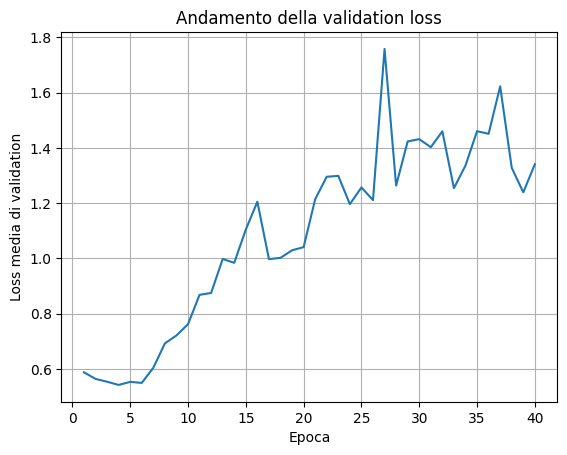

In [93]:
import matplotlib.pyplot as plt

# Curve validation loss
epochs = range(1, len(eval_losses) + 1)

plt.figure()
plt.plot(epochs, eval_losses)
plt.xlabel("Epoca")
plt.ylabel("Loss media di validation")
plt.title("Andamento della validation loss")
plt.grid(True)

plt.show()


## Applico Early stopping

In [96]:

import torch

def train_model_conVal_overfitt(
    model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5,

    # EARLY STOPPING
    patience=5,
    min_delta=0.0,
    save_path="best_model.pt",

    use_scheduler=True,
    lr_factor=0.5,
    lr_patience=2,
    min_lr=1e-6,
    clip_grad_norm=1.0,
    log_every=50
):
    train_losses = []
    eval_losses  = []

    best_val = float("inf")
    bad_epochs = 0

    for epoch in range(num_epochs):
        print(f"\nEPOCH {epoch+1}")
        model.train()  # modalità training

        running_loss = 0.0  # somma loss training epoca

        for i, (batch_ids, batch_labels, batch_texts, batch_mask) in enumerate(train_loader):

            batch_ids    = batch_ids.to(device)
            batch_labels = batch_labels.to(device)
            batch_mask   = batch_mask.to(device)

            optimizer.zero_grad()

            logits = model(batch_ids, batch_mask)
            labels_flat = batch_labels.float()

            loss = criterion(logits, labels_flat)

            loss.backward()
            optimizer.step()

            J = loss.item()
            running_loss += J * batch_ids.size(0)

            if i % log_every == 0:
                print(f"  train batch {i:3d}  loss = {J:.4f}")

        train_epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_epoch_loss)

        # =========================
        # VALIDATION
        # =========================

        # Finita un epoca di training, valuto l'errore medio su tutto il validation set
        model.eval()  # modalità eval

        running_eval_loss = 0.0  # accumula la loss di ogni batch calcolata sul validation set

        with torch.no_grad():
            for batch_ids, batch_labels, batch_texts, batch_mask in val_loader:

                batch_ids    = batch_ids.to(device)
                batch_labels = batch_labels.to(device)
                batch_mask   = batch_mask.to(device)

                logits = model(batch_ids, batch_mask)
                labels_flat = batch_labels.float()

                loss = criterion(logits, labels_flat)

                J = loss.item()
                running_eval_loss += J * batch_ids.size(0)

        eval_epoch_loss = running_eval_loss / len(val_loader.dataset)
        eval_losses.append(eval_epoch_loss)

        print(f"Loss media VAL   epoca {epoch+1}: {eval_epoch_loss:.4f}")

        # =========================
        # EARLY STOPPING (SOLO QUESTO)
        # =========================
        improved = (best_val - eval_epoch_loss) > min_delta

        if improved:
            best_val = eval_epoch_loss
            bad_epochs = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ New best saved: val={best_val:.4f}")
        else:
            bad_epochs += 1
            print(f"  ⚠️ No val improvement. bad_epochs={bad_epochs}/{patience}")

            if bad_epochs >= patience:
                print("🛑 Early stopping triggered (validation stopped improving).")
                break

    # ricarico il best model
    model.load_state_dict(torch.load(save_path, map_location=device))
    print(f"\n✅ Loaded BEST model from {save_path} (best val={best_val:.4f})")

    return model, train_losses, eval_losses

      


In [97]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1) device (GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) modello
model = IronyEndToEndModel(
    dim_vocabolario=len(vocabolario),
    dim_wordVector=128,
    dim_frase=64,
    num_heads=4
).to(device)

# 3) loss
criterion = nn.BCEWithLogitsLoss()

# 4) optimizer (ANTI-OVERFITTING: AdamW + weight decay)
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-2   # regolarizzazione L2 (prova anche 1e-3 se troppo forte)
)

# 5) epoche (puoi mettere alto: si ferma da solo con early stopping)
num_epochs = 200

# 6) training + validation + anti-overfitting (early stopping, scheduler, clipping)
model, train_losses, eval_losses = train_model_conVal_overfitt(
    model,
    train_loader_ALL,   # training loader (dallo split)
    val_loader_ALL,     # validation loader (dallo split)
    criterion,
    optimizer,
    device,
    num_epochs=num_epochs,

    # EARLY STOPPING
    patience=5,
    min_delta=0.0,
    save_path="best_model.pt",

    # LR scheduler su validation loss
    use_scheduler=True,
    lr_factor=0.5,
    lr_patience=2,
    min_lr=1e-6,

    # gradient clipping
    clip_grad_norm=1.0,

    # logging
    log_every=50
)



EPOCH 1
  train batch   0  loss = 0.6970
  train batch  50  loss = 0.5917
  train batch 100  loss = 0.6969
  train batch 150  loss = 0.6332
Loss media VAL   epoca 1: 0.5954
  ✅ New best saved: val=0.5954

EPOCH 2
  train batch   0  loss = 0.5285
  train batch  50  loss = 0.6493
  train batch 100  loss = 0.4336
  train batch 150  loss = 0.5344
Loss media VAL   epoca 2: 0.5567
  ✅ New best saved: val=0.5567

EPOCH 3
  train batch   0  loss = 0.5061
  train batch  50  loss = 0.5645
  train batch 100  loss = 0.4217
  train batch 150  loss = 0.4127
Loss media VAL   epoca 3: 0.5772
  ⚠️ No val improvement. bad_epochs=1/5

EPOCH 4
  train batch   0  loss = 0.4179
  train batch  50  loss = 0.3768
  train batch 100  loss = 0.5209
  train batch 150  loss = 0.2561
Loss media VAL   epoca 4: 0.5505
  ✅ New best saved: val=0.5505

EPOCH 5
  train batch   0  loss = 0.3328
  train batch  50  loss = 0.3698
  train batch 100  loss = 0.5129
  train batch 150  loss = 0.4789
Loss media VAL   epoca 5: 0.58

C:\Users\marco\AppData\Local\Temp\ipykernel_15292\34622548.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=dev

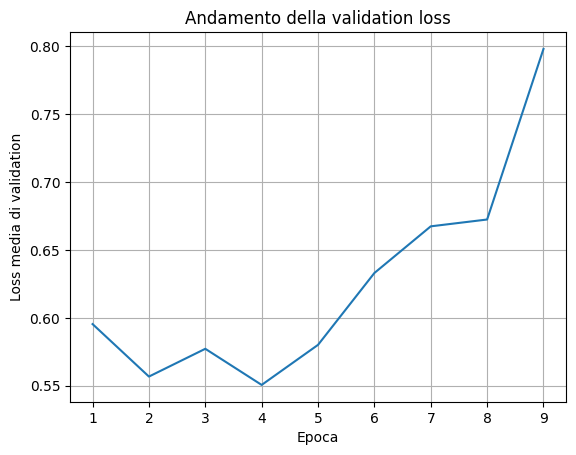

In [98]:
import matplotlib.pyplot as plt

# Curve validation loss
epochs = range(1, len(eval_losses) + 1)

plt.figure()
plt.plot(epochs, eval_losses)
plt.xlabel("Epoca")
plt.ylabel("Loss media di validation")
plt.title("Andamento della validation loss")
plt.grid(True)

plt.show()

# EVALUATION TEST DATASET

In [99]:
Tensor_TestAll

test_loader_ALL = DataLoader(
    Tensor_TestAll,
    batch_size=32,
    shuffle=False  # non deve rimescolare a ogni epoca, è solo un test
)

In [100]:
def evaluate_on_test(model, test_loader, criterion, device):
    model.eval()  # modalità evaluation
    running_loss = 0.0

    all_texts = []
    all_labels = []
    all_logits = []
    all_probs = []
    all_preds = []

    with torch.no_grad():  # niente gradienti
        for batch_ids, batch_labels, batch_texts, batch_mask in test_loader:

            batch_ids    = batch_ids.to(device)
            batch_labels = batch_labels.to(device)
            batch_mask   = batch_mask.to(device)

            # forward
            logits = model(batch_ids, batch_mask)  # [B]
            labels_flat = batch_labels.float()

            # loss
            loss = criterion(logits, labels_flat)
            running_loss += loss.item() * batch_ids.size(0)

            # sigmoid → probabilità
            probs = torch.sigmoid(logits)

            # predizione binaria
            preds = (probs >= 0.5).long()

            # salvataggio risultati
            all_texts.extend(batch_texts)
            all_labels.extend(batch_labels.cpu().tolist())
            all_logits.extend(logits.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

    test_loss = running_loss / len(test_loader.dataset)

    print(f"\n📊 Test loss media: {test_loss:.4f}")

    return test_loss, all_texts, all_labels, all_logits, all_probs, all_preds


In [101]:
# ORA DEVO USARE il model e il criterio definiti prima


test_loss, texts, labels, logits, probs, preds = evaluate_on_test(
    model,
    test_loader_ALL,
    criterion,
    device
)


📊 Test loss media: 0.5236


In [102]:
import pandas as pd

results_df = pd.DataFrame({
    "text": texts,
    "label_reale": labels,
    "predizione": preds
})

results_df.head(100)


,text,label_reale,predizione
0,competenze dei docenti e loro capacità nelle a...,0.0,0
1,"mi piace guardare le collezioni degli altri, m...",0.0,0
2,adesso come lo diciamo alla santanche che il p...,1.0,1
3,“la buona scuola”? fa gli errori di grammatica,0.0,1
4,foto bellissima! un buongiorno grintoso anche ...,0.0,1
...,...,...,...
95,non mi piace dover spendere soldi per ripararl...,0.0,0
96,che splendore quando fai un'apertura video e i...,1.0,1
97,bellissimo vedere che l'hotel ha scritto puliz...,1.0,1
98,chissà chi paga la pensione ai saccenti non di...,1.0,1


In [103]:
accuracy = (results_df["label_reale"] == results_df["predizione"]).mean()
print(f"🎯 Test accuracy: {accuracy * 100:.2f}%")


🎯 Test accuracy: 75.08%
